In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# =========================
# LOAD DAILY DATA
# =========================
daily = pd.read_parquet("nifty100_daily_clean.parquet")

daily.columns = daily.columns.str.lower()
daily["date"] = pd.to_datetime(daily["date"])

daily = daily.sort_values(["symbol", "date"]).reset_index(drop=True)

In [2]:
#rsi only
def rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    rs = gain.rolling(period).mean() / loss.rolling(period).mean()
    return 100 - (100 / (1 + rs))

daily["rsi"] = daily.groupby("symbol")["close"].apply(rsi).reset_index(drop=True)
daily["rsi_change_3d"] = daily.groupby("symbol")["rsi"].diff(3)

In [3]:
daily["box_high"] = daily.groupby("symbol")["high"].apply(
    lambda x: x.rolling(15).max().shift(1)
).reset_index(drop=True)

daily["box_low"] = daily.groupby("symbol")["low"].apply(
    lambda x: x.rolling(15).min().shift(1)
).reset_index(drop=True)

daily["box_range_pct"] = (daily["box_high"] - daily["box_low"]) / daily["box_low"]

range_5d = daily.groupby("symbol")["high"].apply(lambda x: x.rolling(5).max()).reset_index(drop=True) - \
           daily.groupby("symbol")["low"].apply(lambda x: x.rolling(5).min()).reset_index(drop=True)

range_10d = daily.groupby("symbol")["high"].apply(lambda x: x.rolling(10).max()).reset_index(drop=True) - \
            daily.groupby("symbol")["low"].apply(lambda x: x.rolling(10).min()).reset_index(drop=True)

daily["box_tight"] = (daily["box_range_pct"] <= 0.12) & (range_5d < range_10d)

In [4]:
daily["vol_20d_avg"] = daily.groupby("symbol")["volume"].apply(
    lambda x: x.rolling(20).mean()
).reset_index(drop=True)

daily["volume_surge"] = daily["volume"] > 1.3 * daily["vol_20d_avg"]

In [5]:
daily["rsi_ready"] = (daily["rsi"] >= 50) & (daily["rsi_change_3d"] >= 3)

In [6]:
daily["b3_lite_signal"] = (
    (daily["close"] > daily["box_high"]) &
    daily["box_tight"] &
    daily["volume_surge"] &
    daily["rsi_ready"]
)

In [7]:
daily["entry_price"] = daily["box_high"]
daily["target"] = daily["entry_price"] * 1.10   # +10%
daily["stop"] = daily["entry_price"] * 0.97     # -3%

In [8]:
daily["next_high"] = daily.groupby("symbol")["high"].shift(-1)
daily["next_low"] = daily.groupby("symbol")["low"].shift(-1)
daily["next_close"] = daily.groupby("symbol")["close"].shift(-1)

# 🔥 Reset index ONCE – kills all alignment bugs
daily = daily.reset_index(drop=True)

In [9]:
entries = daily[daily["b3_lite_signal"]].copy()

In [10]:
entries["exit_price"] = np.where(
    entries["next_high"] >= entries["target"],
    entries["target"],
    np.where(
        entries["next_low"] <= entries["stop"],
        entries["stop"],
        entries["next_close"]
    )
)

entries["pnl_pct"] = (
    entries["exit_price"] - entries["entry_price"]
) / entries["entry_price"]

In [11]:
trades = len(entries)
win_rate = (entries["pnl_pct"] > 0).mean()
avg_win = entries.loc[entries["pnl_pct"] > 0, "pnl_pct"].mean()
avg_loss = entries.loc[entries["pnl_pct"] <= 0, "pnl_pct"].mean()

print("Trades:", trades)
print("Win rate:", round(win_rate * 100, 2), "%")
print("Avg win %:", round(avg_win * 100, 2))
print("Avg loss %:", round(avg_loss * 100, 2))

Trades: 2340
Win rate: 79.53 %
Avg win %: 2.59
Avg loss %: -1.14


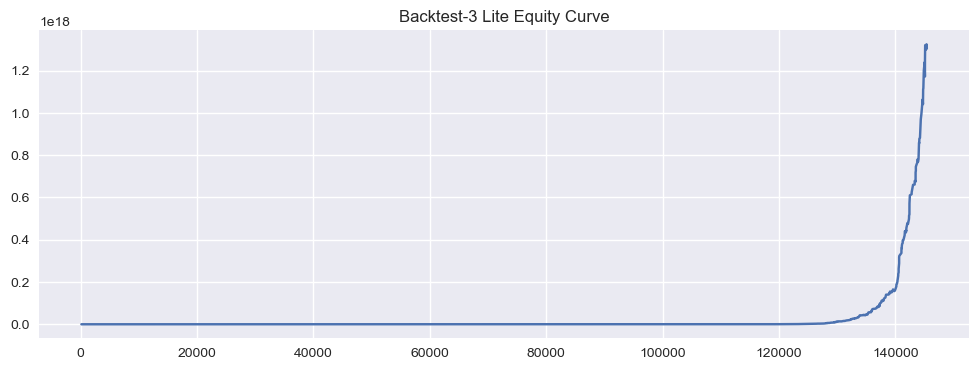

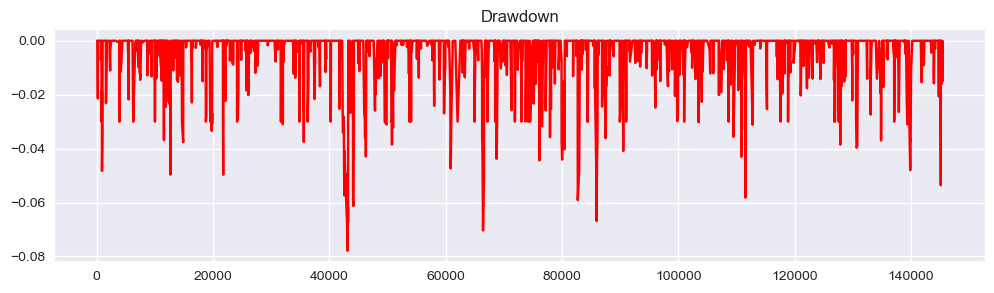

Max Drawdown: -7.79 %


In [12]:
entries["equity"] = (1 + entries["pnl_pct"]).cumprod()

plt.figure(figsize=(12,4))
plt.plot(entries["equity"])
plt.title("Backtest-3 Lite Equity Curve")
plt.show()

dd = entries["equity"] / entries["equity"].cummax() - 1

plt.figure(figsize=(12,3))
plt.plot(dd, color="red")
plt.title("Drawdown")
plt.show()

print("Max Drawdown:", round(dd.min() * 100, 2), "%")

In [13]:
# Exit reason
entries["exit_reason"] = np.where(
    entries["next_high"] >= entries["target"], "TARGET",
    np.where(entries["next_low"] <= entries["stop"], "STOP", "TIME_EXIT")
)

# Exit date (next trading day)
entries["exit_date"] = entries.groupby("symbol")["date"].shift(-1)

# Holding days
entries["holding_days"] = (entries["exit_date"] - entries["date"]).dt.days

# MTM P&L (₹ normalized, assume 1 unit)
entries["mtm_pnl"] = entries["pnl_pct"]

In [14]:
# Exit reason
entries["exit_reason"] = np.where(
    entries["next_high"] >= entries["target"], "TARGET",
    np.where(entries["next_low"] <= entries["stop"], "STOP", "TIME_EXIT")
)

# Exit date (next trading day)
entries["exit_date"] = entries.groupby("symbol")["date"].shift(-1)

# Holding days
entries["holding_days"] = (entries["exit_date"] - entries["date"]).dt.days

# MTM P&L (₹ normalized, assume 1 unit)
entries["mtm_pnl"] = entries["pnl_pct"]

In [16]:
entries = entries.sort_values("date")
entries["strategy_equity"] = (1 + entries["pnl_pct"]).cumprod()
entries["strategy_return"] = entries["strategy_equity"].pct_change()

# Drawdown
entries["strategy_peak"] = entries["strategy_equity"].cummax()
entries["strategy_dd"] = entries["strategy_equity"] / entries["strategy_peak"] - 1

C:\Users\Sanket khandelwal\AppData\Local\Temp\ipykernel_20608\3811351405.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  entries["strategy_return"] = entries["strategy_equity"].pct_change()


In [17]:
nifty = pd.read_excel("Nifty50Close.xlsx")
nifty.columns = nifty.columns.str.lower()
nifty["date"] = pd.to_datetime(nifty["date"])

nifty["return"] = nifty["close"].pct_change()
nifty["equity"] = (1 + nifty["return"]).cumprod()
nifty["peak"] = nifty["equity"].cummax()
nifty["dd"] = nifty["equity"] / nifty["peak"] - 1

In [18]:
def perf_metrics(equity, returns):
    years = (equity.index[-1] - equity.index[0]).days / 365
    cagr = equity.iloc[-1] ** (1 / years) - 1
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
    max_dd = (equity / equity.cummax() - 1).min()
    return cagr, sharpe, max_dd


strategy_cagr, strategy_sharpe, strategy_dd = perf_metrics(
    entries.set_index("date")["strategy_equity"],
    entries["strategy_return"]
)

nifty_cagr, nifty_sharpe, nifty_dd = perf_metrics(
    nifty.set_index("date")["equity"],
    nifty["return"]
)

In [19]:
summary = pd.DataFrame({
    "Metric": ["CAGR", "Sharpe", "Max Drawdown"],
    "Backtest_3_Lite": [strategy_cagr, strategy_sharpe, strategy_dd],
    "NIFTY": [nifty_cagr, nifty_sharpe, nifty_dd]
})

In [20]:
exit_stats = entries["exit_reason"].value_counts(normalize=True) * 100

holding_stats = {
    "Avg Holding Days": entries["holding_days"].mean(),
    "Median Holding Days": entries["holding_days"].median(),
    "Max Holding Days": entries["holding_days"].max()
}

In [21]:
stock_perf = (
    entries.groupby("symbol")["pnl_pct"]
    .sum()
    .sort_values(ascending=False)
)

top_stocks = stock_perf.head(10)
worst_stocks = stock_perf.tail(10)

In [22]:
monthly_perf = (
    entries.set_index("date")["pnl_pct"]
    .resample("M")
    .sum()
)

C:\Users\Sanket khandelwal\AppData\Local\Temp\ipykernel_20608\1266002772.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


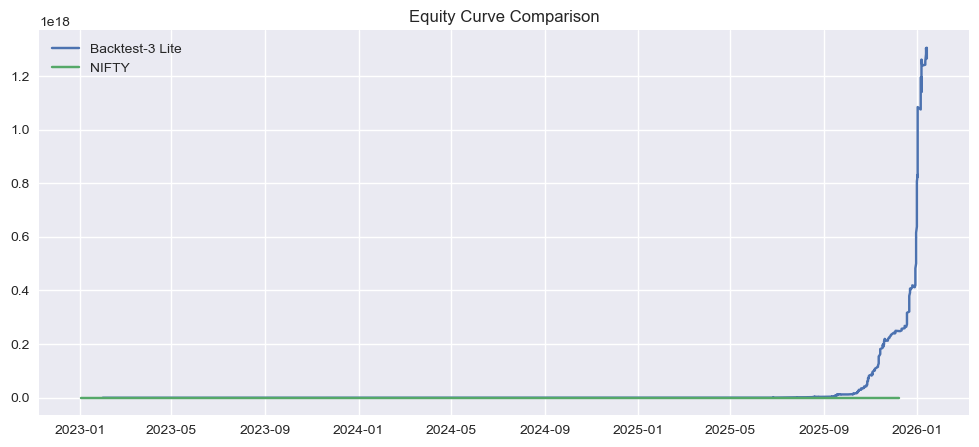

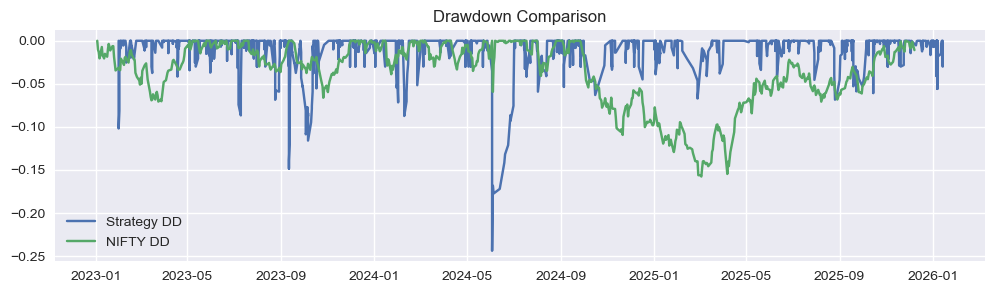

In [23]:
plt.figure(figsize=(12,5))
plt.plot(entries["date"], entries["strategy_equity"], label="Backtest-3 Lite")
plt.plot(nifty["date"], nifty["equity"], label="NIFTY")
plt.legend()
plt.title("Equity Curve Comparison")
plt.show()

plt.figure(figsize=(12,3))
plt.plot(entries["date"], entries["strategy_dd"], label="Strategy DD")
plt.plot(nifty["date"], nifty["dd"], label="NIFTY DD")
plt.legend()
plt.title("Drawdown Comparison")
plt.show()

In [24]:
with pd.ExcelWriter("Backtest3_Lite_Report.xlsx", engine="xlsxwriter") as writer:
    entries.to_excel(writer, sheet_name="Trade_Log", index=False)
    summary.to_excel(writer, sheet_name="Summary_Metrics", index=False)
    monthly_perf.to_frame("Monthly_Return").to_excel(writer, sheet_name="Monthly_Performance")
    exit_stats.to_frame("Exit_%").to_excel(writer, sheet_name="Exit_Analysis")
    top_stocks.to_frame("Total_PnL").to_excel(writer, sheet_name="Top_Stocks")
    worst_stocks.to_frame("Total_PnL").to_excel(writer, sheet_name="Worst_Stocks")
    nifty.to_excel(writer, sheet_name="Benchmark_NIFTY", index=False)